# ClauseRisk v1 – Baseline Out-of-Distribution Evaluation

This notebook implements the baseline evaluation of **ClauseRisk** on an external out-of-distribution (OOD) dataset. The objective is to assess the generalization capability of different risk classification approaches using unseen legal and contractual texts.

---

## Evaluation Overview

The evaluation framework uses:

* A legal knowledge base containing annotated clauses.
* An external benchmark composed of real-world passages collected from multiple digital platforms and online services.
* Standard classification metrics to compare baseline machine learning models and retrieval-augmented approaches.

---

## Compared Methods

The notebook evaluates the following approaches:

| Method                          | Description                                   |
| ------------------------------- | --------------------------------------------- |
| Random Baseline                 | Random class prediction                       |
| Majority Baseline               | Majority class prediction                     |
| TF-IDF + Logistic Regression    | Classical machine learning baseline           |
| TF-IDF + Support Vector Machine | Classical machine learning baseline           |
| TF-IDF + Random Forest          | Ensemble learning baseline                    |
| TF-IDF + Gradient Boosting      | Ensemble learning baseline                    |
| mBERT Zero-Shot                 | Transformer-based baseline                    |
| BM25 + Rule-Based Retrieval     | Retrieval-based baseline                      |
| ClauseRisk (BM25 + LLM)         | Retrieval-Augmented Generation (RAG) approach |

---

## Required Files

Before running the notebook, upload the following files:

* `kb_compact.json`
* `EVAL_external_ENRICHED_MASSIVE.xlsx`

---

## Evaluation Metrics

The evaluated methods are compared using standard classification metrics, including:

* Accuracy
* Precision
* Recall
* F1-score
* Macro F1-score
* Confusion Matrix

---

## Output

The notebook generates:

* Predictions for all evaluated methods.
* Comparative performance metrics.
* Classification reports.
* Confusion matrices.
* A comparative benchmark of baseline and ClauseRisk approaches.


## 1. Installation et imports

In [ ]:
!pip install -q openai scikit-learn pandas openpyxl matplotlib seaborn numpy tqdm
!pip install -q transformers torch sentence-transformers sentencepiece
print("✓ Dépendances installées")

✓ Dépendances installées


In [ ]:
import os, json, re, time, math, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score, classification_report)

warnings.filterwarnings('ignore')
np.random.seed(42)

COLORS_METHOD = {
    'Random':'#9CA3AF','Majority':'#6B7280','TF-IDF + LogReg':'#3B82F6',
    'TF-IDF + SVM':'#1E40AF','TF-IDF + RF':'#7C3AED','TF-IDF + GB':'#A855F7',
    'mBERT zero-shot':'#EC4899','BM25 + Rule':'#F59E0B','ClauseRisk (BM25+LLM)':'#10B981',
}
RISK_ORDER = {'none':0,'low':1,'medium':2,'high':3}
print("✓ Imports OK")

✓ Imports OK


## 2. Upload des 2 fichiers

In [ ]:
from google.colab import files
print("📂 Upload les DEUX fichiers : kb_compact.json ET EVAL_external_ENRICHED_MASSIVE.xlsx")
uploaded = files.upload()
print("\n✓ Fichiers reçus :", list(uploaded.keys()))

# Identifier les fichiers
kb_file = next((f for f in uploaded if f.endswith('.json')), None)
xlsx_file = next((f for f in uploaded if f.endswith('.xlsx')), None)
assert kb_file, "❌ kb_compact.json manquant !"
assert xlsx_file, "❌ fichier Excel manquant !"
print(f"   KB    : {kb_file}")
print(f"   Test  : {xlsx_file}")

📂 Upload les DEUX fichiers : kb_compact.json ET EVAL_external_ENRICHED_MASSIVE.xlsx


Saving EVAL_external_ENRICHED_MASSIVE.xlsx to EVAL_external_ENRICHED_MASSIVE (2).xlsx
Saving kb_compact.json to kb_compact (2).json

✓ Fichiers reçus : ['EVAL_external_ENRICHED_MASSIVE (2).xlsx', 'kb_compact (2).json']
   KB    : kb_compact (2).json
   Test  : EVAL_external_ENRICHED_MASSIVE (2).xlsx


## 3. Charger la base de connaissances (données d'entraînement)

In [ ]:
with open(kb_file, 'r', encoding='utf-8') as f:
    KB = json.load(f)
df_kb = pd.DataFrame(KB)
df_kb['rl'] = df_kb['rl'].astype(str).str.lower().str.strip()
df_kb = df_kb[df_kb['rl'].isin(['none','low','medium','high'])].reset_index(drop=True)
print(f"📊 KB chargée : {len(df_kb)} clauses")
print(df_kb['rl'].value_counts().to_string())

# Pour l'entraînement ML : exclure les 'No match'
df_train = df_kb[~df_kb['rc'].astype(str).str.lower().str.startswith('no match')].reset_index(drop=True)
print(f"\nClauses pour entraînement ML (sans 'No match') : {len(df_train)}")
print(df_train['rl'].value_counts().to_string())

📊 KB chargée : 315 clauses
rl
low       203
medium     64
high       48

Clauses pour entraînement ML (sans 'No match') : 285
rl
low       173
medium     64
high       48


## 4. Charger le corpus de test externe (81 passages)⚠️ Ce sont des passages que les modèles n'ont **jamais vus**. C'est le cœur du test out-of-distribution.

In [ ]:
df_test = pd.read_excel(xlsx_file, sheet_name='passages')
# Garder seulement les lignes annotées
df_test = df_test[df_test['passage_text'].notna() & df_test['expected_risk_level'].notna()].copy()
df_test['expected_risk_level'] = df_test['expected_risk_level'].astype(str).str.lower().str.strip()
df_test = df_test[df_test['expected_risk_level'].isin(['none','low','medium','high'])].reset_index(drop=True)

print(f"📊 Corpus de test : {len(df_test)} passages externes")
print(f"\nPar langue :")
print(df_test['language'].value_counts().to_string())
print(f"\nPar niveau de risque (vérité terrain) :")
print(df_test['expected_risk_level'].value_counts().to_string())
print(f"\nNombre de sites différents : {df_test['source_app'].nunique()}")

y_test = df_test['expected_risk_level'].values

📊 Corpus de test : 81 passages externes

Par langue :
language
fr    36
en    26
ar    19

Par niveau de risque (vérité terrain) :
expected_risk_level
high      37
medium    26
low       18

Nombre de sites différents : 42


## 5. Préprocessing multilingue (identique au pipeline production)

In [ ]:
import unicodedata
STOPWORDS = set("the a an and or of to in on at for by with is are was were be been this that these those it as from but if not no any all may shall will can such which who whom le la les un une des de du et ou a au aux en sur pour par avec est sont ce cette ces il elle ils elles que qui dans leur leurs plus tout tous aussi mais si ne pas في من إلى على عن مع هذا هذه الذي التي أن و أو لا ما قد كل عند بين تحت فوق قبل بعد لكن إذا لم لن كان كانت".split())

def normalize_text(text, lang):
    if not isinstance(text, str): return ""
    t = text.lower()
    t = re.sub(r"[.,;:!?\[\]\(\)\{\}\"'«»\-—–_/\\@#$%^&*+=<>~`|]", " ", t)
    if lang == "ar":
        t = re.sub(r"[\u064B-\u065F\u0670\u0640]", "", t)
        t = re.sub(r"[\u0622\u0623\u0625]", "\u0627", t)
        t = re.sub(r"\u0649", "\u064A", t); t = re.sub(r"\u0629", "\u0647", t)
    else:
        t = unicodedata.normalize("NFD", t)
        t = "".join(c for c in t if unicodedata.category(c) != "Mn")
    return t

def tokenize(text, lang):
    return [w for w in normalize_text(text, lang).split() if len(w) > 1 and w not in STOPWORDS]

def detect_lang(text):
    if not text: return 'en'
    ar = len(re.findall(r'[\u0600-\u06FF]', text[:2000]))
    if ar / (len(re.sub(r'\s','',text[:2000])) or 1) > 0.15: return 'ar'
    low = text.lower()[:2000]
    fr = len(re.findall(r'\b(le|la|les|des|du|et|une|cette|sont|nous|vous|qui|dans|par|pour|avec)\b', low))
    en = len(re.findall(r'\b(the|of|and|to|in|that|is|are|was|with|for|by|this|shall)\b', low))
    return 'fr' if fr > en else 'en'

# KB multilingue concaténée pour TF-IDF / BERT
def kb_text(row):
    parts = [str(row.get('en','')), str(row.get('fr','')), str(row.get('ar',''))]
    return ' '.join(normalize_text(p, l) for p,l in zip(parts,['en','fr','ar']) if p and p!='nan')
df_train['text_all'] = df_train.apply(kb_text, axis=1)

# Test : on prend le passage_text dans sa langue
df_test['text_norm'] = df_test.apply(lambda r: normalize_text(str(r['passage_text']), r['language']), axis=1)
print("✓ Préprocessing terminé")
print(f"   Exemple KB : {df_train['text_all'].iloc[0][:120]}...")
print(f"   Exemple test : {df_test['text_norm'].iloc[0][:120]}...")

✓ Préprocessing terminé
   Exemple KB : disputes are interpreted in accordance with external law regardless of the location of the user  les litiges sont interp...
   Exemple test : you will bring any complaint  lawsuit  or dispute   claim   arising out of or relating to this statement or to facebook ...


## 6. Fonction d'évaluation commune

In [ ]:
results = {}
def evaluate(name, y_true, y_pred, latency_ms=0):
    labels = ['low','medium','high']  # 'none' rare dans le test externe
    p,r,f1,_ = precision_recall_fscore_support(y_true,y_pred,average='macro',labels=labels,zero_division=0)
    pw,rw,f1w,_ = precision_recall_fscore_support(y_true,y_pred,average='weighted',labels=labels,zero_division=0)
    acc = accuracy_score(y_true,y_pred)
    kappa = cohen_kappa_score(y_true,y_pred)
    results[name] = {'accuracy':acc,'precision_macro':p,'recall_macro':r,'f1_macro':f1,
                     'f1_weighted':f1w,'kappa':kappa,'latency_ms':latency_ms,'y_pred':list(y_pred)}
    print(f"  {name:<28} acc={acc:.3f}  F1_macro={f1:.3f}  F1_weighted={f1w:.3f}  κ={kappa:.3f}")

## 7. Baselines naïves (B0, B1)

In [ ]:
# B0 Random
np.random.seed(42)
evaluate('Random', y_test, np.random.choice(['low','medium','high'], size=len(y_test)))
# B1 Majority
maj = pd.Series(df_train['rl']).value_counts().idxmax()
evaluate('Majority', y_test, np.array([maj]*len(y_test)))

  Random                       acc=0.309  F1_macro=0.297  F1_weighted=0.307  κ=-0.053
  Majority                     acc=0.222  F1_macro=0.121  F1_weighted=0.081  κ=0.000


## 8. Méthodes ML classiques (B2-B5)**Entraînées sur la KB**, testées sur les 81 passages externes.

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True)
X_train = vectorizer.fit_transform(df_train['text_all'])
X_test = vectorizer.transform(df_test['text_norm'])
y_train = df_train['rl'].values
print(f"TF-IDF : train {X_train.shape}, test {X_test.shape}")

# B2 LogReg
t=time.time(); clf=LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42).fit(X_train,y_train)
evaluate('TF-IDF + LogReg', y_test, clf.predict(X_test), (time.time()-t)*1000/len(y_test))
# B3 SVM
t=time.time(); clf=LinearSVC(class_weight='balanced',max_iter=5000,random_state=42).fit(X_train,y_train)
evaluate('TF-IDF + SVM', y_test, clf.predict(X_test), (time.time()-t)*1000/len(y_test))
# B4 RF
t=time.time(); clf=RandomForestClassifier(n_estimators=200,max_depth=20,class_weight='balanced',n_jobs=-1,random_state=42).fit(X_train,y_train)
evaluate('TF-IDF + RF', y_test, clf.predict(X_test), (time.time()-t)*1000/len(y_test))
# B5 GB
t=time.time(); clf=GradientBoostingClassifier(n_estimators=100,max_depth=5,random_state=42).fit(X_train,y_train)
evaluate('TF-IDF + GB', y_test, clf.predict(X_test), (time.time()-t)*1000/len(y_test))

TF-IDF : train (285, 2521), test (81, 2521)
  TF-IDF + LogReg              acc=0.185  F1_macro=0.160  F1_weighted=0.136  κ=-0.110
  TF-IDF + SVM                 acc=0.247  F1_macro=0.211  F1_weighted=0.170  κ=-0.007
  TF-IDF + RF                  acc=0.210  F1_macro=0.182  F1_weighted=0.149  κ=-0.068
  TF-IDF + GB                  acc=0.222  F1_macro=0.169  F1_weighted=0.127  κ=-0.028


## 9. mBERT multilingue zero-shot (B6)

In [ ]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f"✓ mBERT chargé · device: {sbert.device}")

def raw_multi(row):
    parts=[str(row.get('en','')),str(row.get('fr','')),str(row.get('ar',''))]
    return ' '.join(p for p in parts if p and p!='nan')
emb_train = sbert.encode([raw_multi(r) for _,r in df_train.iterrows()], show_progress_bar=True, batch_size=32)
emb_test = sbert.encode(df_test['passage_text'].astype(str).tolist(), show_progress_bar=True, batch_size=32)

t=time.time()
clf=LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42).fit(emb_train,y_train)
evaluate('mBERT zero-shot', y_test, clf.predict(emb_test), (time.time()-t)*1000/len(y_test))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ mBERT chargé · device: cuda:0


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  mBERT zero-shot              acc=0.309  F1_macro=0.276  F1_weighted=0.234  κ=0.062


## 10. BM25 + Rule (B7) — ton RAG sans le LLM

In [ ]:
class BM25Index:
    def __init__(self, kb, lang):
        self.kb=kb; self.lang=lang
        self.docs=[tokenize(c.get(lang,''),lang) for c in kb]
        self.N=len(self.docs); self.df=Counter()
        for d in self.docs: self.df.update(set(d))
        self.dl=[len(d) for d in self.docs]; self.avgdl=sum(self.dl)/max(1,self.N)
    def idf(self,term):
        n=self.df.get(term,0); return math.log(1+(self.N-n+0.5)/(n+0.5))
    def score(self,q,i,k1=1.5,b=0.75):
        doc=self.docs[i]
        if not doc: return 0.0
        tf=Counter(doc); dl=self.dl[i]; s=0.0
        for term in q:
            f=tf.get(term,0)
            if f: s+=self.idf(term)*(f*(k1+1))/(f+k1*(1-b+b*dl/self.avgdl))
        return s
    def retrieve(self,query,k=12):
        q=tokenize(query,self.lang)
        if not q: return []
        res=[]
        for i,c in enumerate(self.kb):
            s=self.score(q,i)
            if s>0: res.append({'idx':i,'score':s,'clause':c})
        res.sort(key=lambda r:r['score'],reverse=True)
        return res[:k]

kb_records = df_kb.to_dict('records')  # KB complète (avec No match) pour la récupération
indices = {l: BM25Index(kb_records, l) for l in ['en','fr','ar']}
print("✓ Index BM25 construits sur la KB complète")

def bm25_rule_classify(text, lang, top_k=5):
    hits = indices[lang].retrieve(text, k=top_k)
    if not hits: return 'low'
    mx='none'
    for h in hits:
        if h['clause'].get('rc','').lower().startswith('no match'): continue
        lvl=h['clause'].get('rl','low').lower()
        if RISK_ORDER.get(lvl,1)>RISK_ORDER.get(mx,0): mx=lvl
    return mx if mx!='none' else 'low'

t=time.time()
preds=[bm25_rule_classify(str(r['passage_text']), r['language']) for _,r in df_test.iterrows()]
evaluate('BM25 + Rule', y_test, np.array(preds), (time.time()-t)*1000/len(y_test))

✓ Index BM25 construits sur la KB complète
  BM25 + Rule                  acc=0.309  F1_macro=0.280  F1_weighted=0.308  κ=-0.046


## 11. ClauseRisk complet (B8) — BM25 + LLM⚠️ Cette étape coûte ~$0.08 pour les 81 passages (gpt-4o-mini).

In [ ]:
from getpass import getpass
api_key = os.environ.get('OPENAI_API_KEY') or getpass("🔐 Clé OpenAI (sk-...) : ").strip()
os.environ['OPENAI_API_KEY']=api_key
from openai import OpenAI
client = OpenAI(api_key=api_key)
print("✓ OpenAI configuré")

🔐 Clé OpenAI (sk-...) : ··········
✓ OpenAI configuré


In [ ]:
def clauserisk_classify(text, lang):
    retrieved = indices[lang].retrieve(text, k=12)
    if not retrieved: return 'low'
    ctx = '\n'.join([f"[{r['clause'].get('id','?')}] (risk={r['clause'].get('rl')}, cat={r['clause'].get('rc')}): {(r['clause'].get(lang) or r['clause'].get('en') or '')[:250]}" for r in retrieved[:12]])
    lang_name={'en':'English','fr':'French','ar':'Arabic'}.get(lang,'English')
    sys_p=f"You are a multilingual legal risk analyst grounded in Algerian law. Use ONLY the retrieved clauses. Respond ONLY with valid JSON: {{\"overall_risk\": \"none|low|medium|high\"}}."
    usr_p=f"USER TEXT ({lang_name}):\n{text[:1500]}\n\nRETRIEVED CLAUSES:\n{ctx}\n\nOutput JSON:"
    try:
        resp=client.chat.completions.create(model='gpt-4o-mini',
            messages=[{'role':'system','content':sys_p},{'role':'user','content':usr_p}],
            temperature=0.1,max_tokens=60,response_format={'type':'json_object'})
        out=json.loads(resp.choices[0].message.content)
        risk=(out.get('overall_risk') or 'low').lower()
        return risk if risk in RISK_ORDER else 'low'
    except Exception as e:
        print(f"  ⚠️ {e}"); return 'low'

preds_llm=[]
t=time.time()
for _,r in tqdm(df_test.iterrows(), total=len(df_test), desc="ClauseRisk LLM"):
    preds_llm.append(clauserisk_classify(str(r['passage_text']), r['language']))
    time.sleep(0.2)
evaluate('ClauseRisk (BM25+LLM)', y_test, np.array(preds_llm), (time.time()-t)*1000/len(df_test))

ClauseRisk LLM:   0%|          | 0/81 [00:00<?, ?it/s]

  ClauseRisk (BM25+LLM)        acc=0.333  F1_macro=0.322  F1_weighted=0.332  κ=0.018


## 12. 🏆 Tableau final — le vrai classement out-of-distribution

In [ ]:
summary=[]
for name,r in results.items():
    summary.append({'Méthode':name,'Accuracy':r['accuracy'],'Precision (macro)':r['precision_macro'],
        'Recall (macro)':r['recall_macro'],'F1 (macro)':r['f1_macro'],'F1 (weighted)':r['f1_weighted'],
        'Cohen κ':r['kappa']})
df_sum=pd.DataFrame(summary).sort_values('F1 (macro)',ascending=False).reset_index(drop=True)
print("="*95)
print("CLASSEMENT OUT-OF-DISTRIBUTION (81 passages externes réels)")
print("="*95)
print(df_sum.to_string(index=False,float_format='%.3f'))
print("="*95)

# Position de ClauseRisk
pos = df_sum.index[df_sum['Méthode']=='ClauseRisk (BM25+LLM)'].tolist()
if pos:
    print(f"\n🎯 ClauseRisk est classé #{pos[0]+1} sur {len(df_sum)} méthodes")

CLASSEMENT OUT-OF-DISTRIBUTION (81 passages externes réels)
              Méthode  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)  Cohen κ
ClauseRisk (BM25+LLM)     0.333              0.364           0.340       0.322          0.332    0.018
               Random     0.309              0.297           0.305       0.297          0.307   -0.053
          BM25 + Rule     0.309              0.296           0.290       0.280          0.308   -0.046
      mBERT zero-shot     0.309              0.540           0.391       0.276          0.234    0.062
         TF-IDF + SVM     0.247              0.181           0.330       0.211          0.170   -0.007
          TF-IDF + RF     0.210              0.146           0.269       0.182          0.149   -0.068
          TF-IDF + GB     0.222              0.144           0.316       0.169          0.127   -0.028
      TF-IDF + LogReg     0.185              0.128           0.226       0.160          0.136   -0.110
             

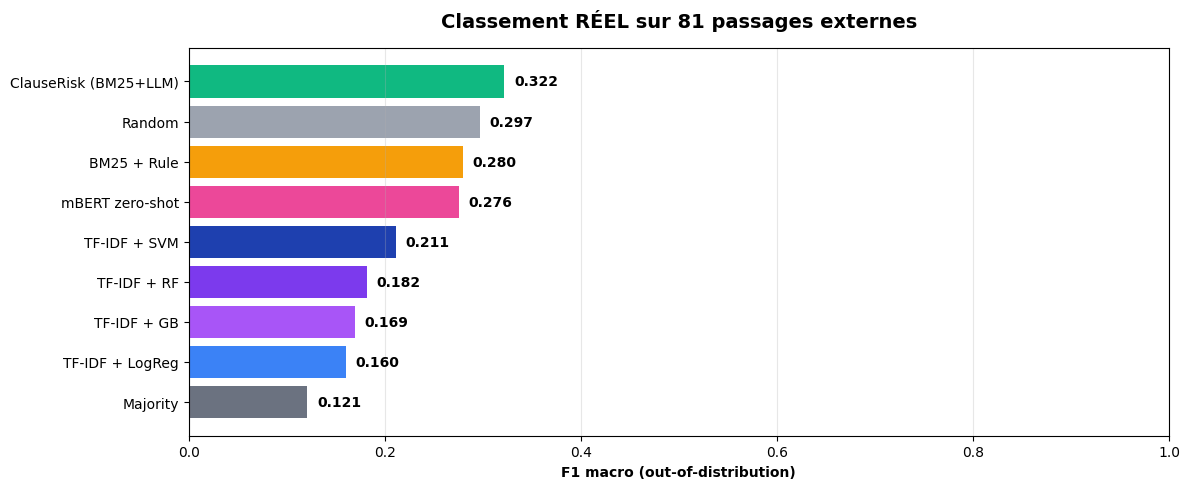

💾 ood_f1_ranking.png


In [ ]:
# Barres comparatives
fig,ax=plt.subplots(figsize=(12,5))
m=df_sum['Méthode'].tolist(); f=df_sum['F1 (macro)'].tolist()
colors=[COLORS_METHOD.get(x,'#6B7280') for x in m]
bars=ax.barh(m,f,color=colors); ax.invert_yaxis()
ax.set_xlabel('F1 macro (out-of-distribution)',fontweight='bold'); ax.set_xlim(0,1)
ax.set_title('Classement RÉEL sur 81 passages externes',fontsize=14,fontweight='bold',pad=15)
for b,v in zip(bars,f): ax.text(b.get_width()+0.01,b.get_y()+b.get_height()/2,f'{v:.3f}',va='center',fontweight='bold')
ax.grid(axis='x',alpha=0.3); plt.tight_layout()
plt.savefig('ood_f1_ranking.png',dpi=200,bbox_inches='tight'); plt.show()
print("💾 ood_f1_ranking.png")

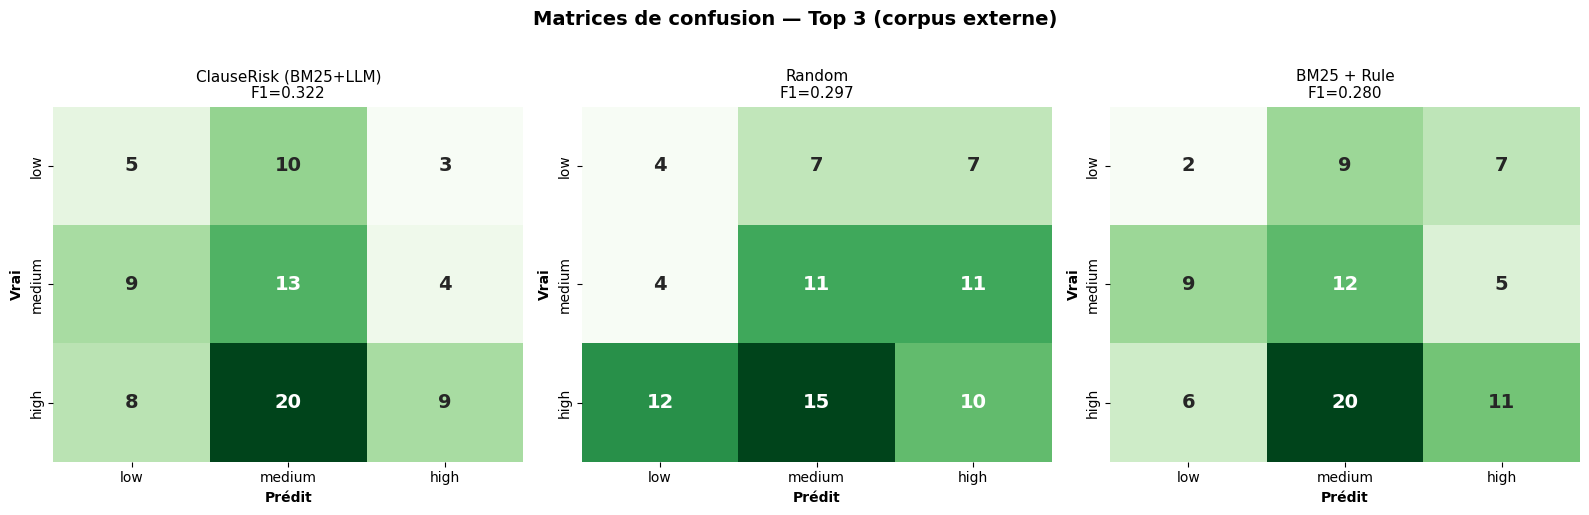

💾 ood_confusion.png


In [ ]:
# Matrices de confusion top 3
top3=df_sum.head(3)['Méthode'].tolist()
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,name in zip(axes,top3):
    cm=confusion_matrix(y_test,results[name]['y_pred'],labels=['low','medium','high'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',xticklabels=['low','medium','high'],
                yticklabels=['low','medium','high'],ax=ax,cbar=False,annot_kws={'size':14,'weight':'bold'})
    ax.set_xlabel('Prédit',fontweight='bold'); ax.set_ylabel('Vrai',fontweight='bold')
    ax.set_title(f'{name}\nF1={results[name]["f1_macro"]:.3f}',fontsize=11)
plt.suptitle('Matrices de confusion — Top 3 (corpus externe)',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('ood_confusion.png',dpi=200,bbox_inches='tight'); plt.show()
print("💾 ood_confusion.png")

## 13. 📊 Comparaison interne vs externe (LE graphique clé pour le jury)Si tu as les chiffres du benchmark interne précédent, ce graphique montre la **chute** des méthodes ML quand on passe en conditions réelles.

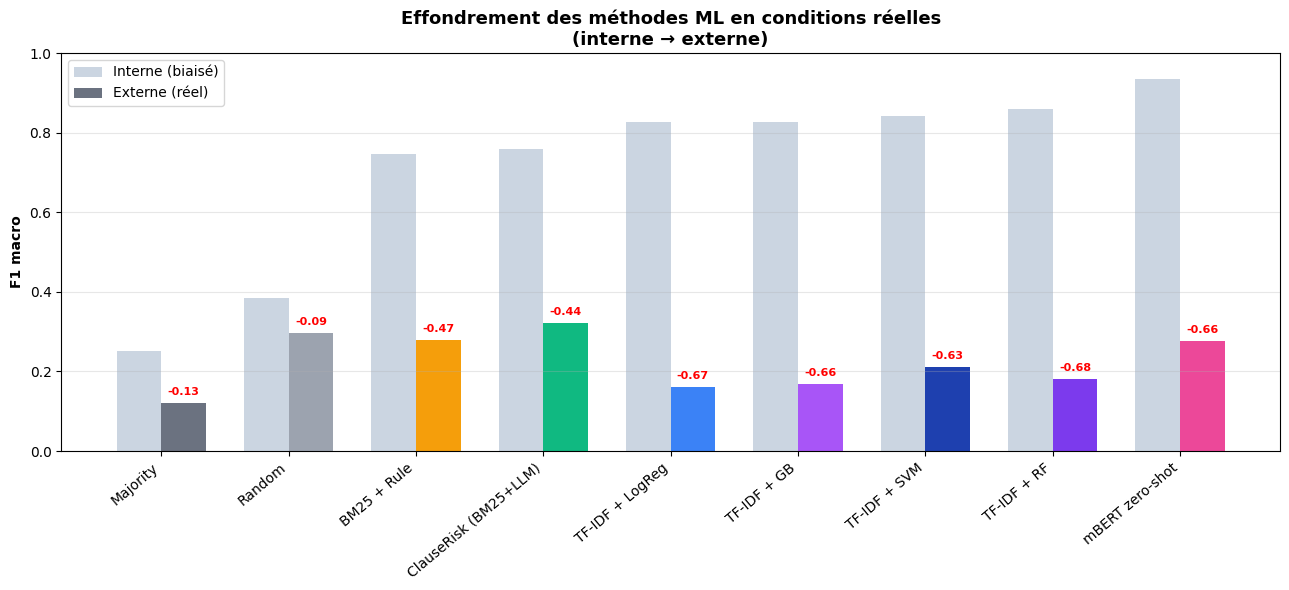

💾 ood_internal_vs_external.png

📉 Chutes (Δ F1 interne→externe) :
   TF-IDF + RF                  0.860 → 0.182  (-0.678)
   TF-IDF + LogReg              0.826 → 0.160  (-0.666)
   mBERT zero-shot              0.934 → 0.276  (-0.658)
   TF-IDF + GB                  0.827 → 0.169  (-0.658)
   TF-IDF + SVM                 0.842 → 0.211  (-0.631)
   BM25 + Rule                  0.747 → 0.280  (-0.467)
   ClauseRisk (BM25+LLM)        0.758 → 0.322  (-0.436)
   Majority                     0.251 → 0.121  (-0.130)
   Random                       0.384 → 0.297  (-0.087)


In [ ]:
internal_f1 = {
    'Majority':0.251,'Random':0.384,'BM25 + Rule':0.747,'ClauseRisk (BM25+LLM)':0.758,
    'TF-IDF + LogReg':0.826,'TF-IDF + GB':0.827,'TF-IDF + SVM':0.842,'TF-IDF + RF':0.860,
    'mBERT zero-shot':0.934,
}
external_f1 = {m: results[m]['f1_macro'] for m in results}

methods = [m for m in internal_f1 if m in external_f1]
x = np.arange(len(methods)); w=0.35
fig,ax=plt.subplots(figsize=(13,6))
b1=ax.bar(x-w/2,[internal_f1[m] for m in methods],w,label='Interne (biaisé)',color='#CBD5E1')
b2=ax.bar(x+w/2,[external_f1[m] for m in methods],w,label='Externe (réel)',
          color=[COLORS_METHOD.get(m,'#6B7280') for m in methods])
ax.set_xticks(x); ax.set_xticklabels(methods,rotation=40,ha='right')
ax.set_ylabel('F1 macro',fontweight='bold'); ax.set_ylim(0,1)
ax.set_title('Effondrement des méthodes ML en conditions réelles\n(interne → externe)',fontsize=13,fontweight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
# Annoter les chutes
for i,m in enumerate(methods):
    delta=external_f1[m]-internal_f1[m]
    ax.text(i+w/2,external_f1[m]+0.02,f'{delta:+.2f}',ha='center',fontsize=8,
            color='red' if delta<-0.05 else 'green',fontweight='bold')
plt.tight_layout(); plt.savefig('ood_internal_vs_external.png',dpi=200,bbox_inches='tight'); plt.show()
print("💾 ood_internal_vs_external.png")
print("\n📉 Chutes (Δ F1 interne→externe) :")
for m in sorted(methods,key=lambda x:external_f1[x]-internal_f1[x]):
    print(f"   {m:<28} {internal_f1[m]:.3f} → {external_f1[m]:.3f}  ({external_f1[m]-internal_f1[m]:+.3f})")

## 14. Analyse par langue et par type de site

In [ ]:
# Performance de ClauseRisk par langue
df_test['pred_clauserisk']=results['ClauseRisk (BM25+LLM)']['y_pred']
print("📊 ClauseRisk — F1 par langue :")
for lang in ['en','fr','ar']:
    mask=df_test['language']==lang
    if mask.sum()>0:
        _,_,f1,_=precision_recall_fscore_support(df_test[mask]['expected_risk_level'],
            df_test[mask]['pred_clauserisk'],average='macro',labels=['low','medium','high'],zero_division=0)
        print(f"   {lang.upper()} ({mask.sum():>2} passages) : F1={f1:.3f}")

print("\n📊 ClauseRisk — Accuracy par strata :")
for strata in ['critical','ambiguous','benign']:
    mask=df_test['strata']==strata
    if mask.sum()>0:
        acc=accuracy_score(df_test[mask]['expected_risk_level'],df_test[mask]['pred_clauserisk'])
        print(f"   {strata:<10} ({mask.sum():>2} passages) : acc={acc:.3f}")

📊 ClauseRisk — F1 par langue :
   EN (26 passages) : F1=0.301
   FR (36 passages) : F1=0.313
   AR (19 passages) : F1=0.297

📊 ClauseRisk — Accuracy par strata :
   critical   (38 passages) : acc=0.237
   ambiguous  (25 passages) : acc=0.520
   benign     (18 passages) : acc=0.278


## 15. Export Excel + téléchargement

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
wb=Workbook(); ws=wb.active; ws.title='OOD_Results'
hdr=list(df_sum.columns)
for c,h in enumerate(hdr,1):
    cell=ws.cell(1,c,h); cell.font=Font(bold=True,color='FFFFFF'); cell.fill=PatternFill('solid',start_color='1F2937')
for r,row in df_sum.iterrows():
    for c,h in enumerate(hdr,1):
        cell=ws.cell(r+2,c,row[h])
        if isinstance(row[h],float): cell.number_format='0.000'
for col in 'ABCDEFG': ws.column_dimensions[col].width=20

# Onglet prédictions détaillées
ws2=wb.create_sheet('Predictions')
cols=['passage_id','language','source_app','expected_risk_level','pred_clauserisk','strata']
for c,h in enumerate(cols,1): ws2.cell(1,c,h).font=Font(bold=True)
for r,(_,row) in enumerate(df_test.iterrows(),2):
    for c,h in enumerate(cols,1):
        ws2.cell(r,c,str(row.get(h,'')))
wb.save('ood_results.xlsx')
print("💾 ood_results.xlsx")

from google.colab import files
for f in ['ood_results.xlsx','ood_f1_ranking.png','ood_confusion.png','ood_internal_vs_external.png']:
    if os.path.exists(f): files.download(f)
print("\n🎉 Évaluation out-of-distribution terminée !")

💾 ood_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Évaluation out-of-distribution terminée !
